In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import quad

In [2]:
omega_m_values, chi2_values = np.load("chi2_values.npy")

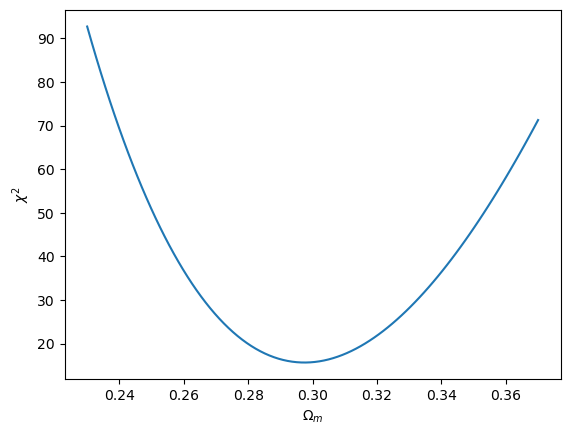

In [3]:
plt.plot(omega_m_values, chi2_values)
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$\chi^2$")
plt.show()

In [4]:
# We have implicitely assumed a flat prior on Omega M~[0.23, 0.37]
posterior = np.exp(-0.5 * chi2_values)
# Normalize the posterior
interp_posterior = interp1d(omega_m_values, posterior, kind="cubic", fill_value="extrapolate")
norm_posterior = quad(interp_posterior, a=0.23, b=0.37)
# Redefine the interpolator of the posterior, with normalized posterior now
interp_posterior = interp1d(omega_m_values, posterior/norm_posterior[0], kind="cubic", fill_value="extrapolate")

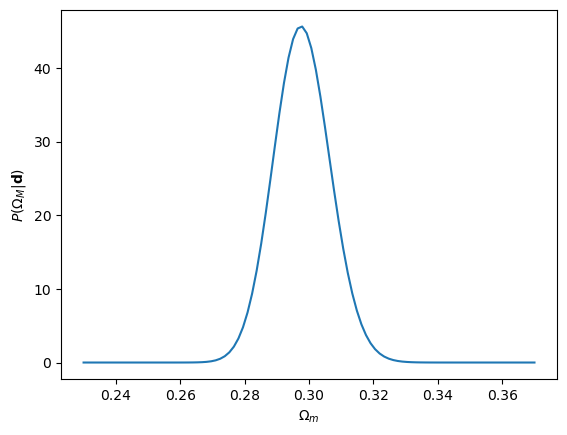

In [5]:
plt.plot(omega_m_values, posterior/norm_posterior[0])
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$P(\Omega_M|\mathbf{d})$")
plt.show()
posterior = posterior/norm_posterior[0]

# Sample from the posterior using the Inverse cumulative method

In [6]:
# Compute the cumulative of the posterior, by integration
cumfunc = np.array([quad(interp_posterior, a=0.23, b=om)[0] for om in omega_m_values])

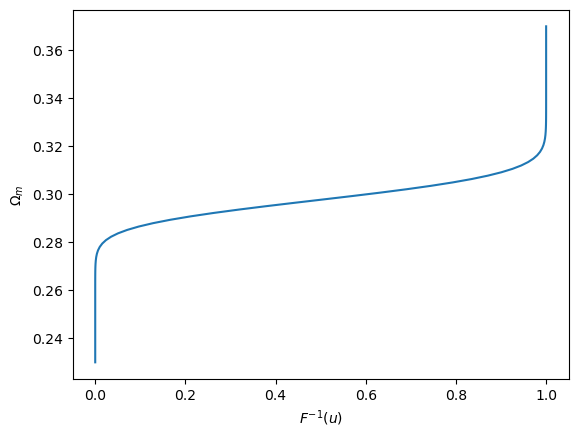

In [7]:
#Plot the normalized cumulative posterior
plt.plot(cumfunc, omega_m_values)
plt.xlabel("$F^{-1}(u)$")
plt.ylabel(r"$\Omega_m$")
plt.show()

In [8]:
# Create a continuous function from the grid
interp_inverse_cumulative = interp1d(cumfunc, omega_m_values, kind="linear")

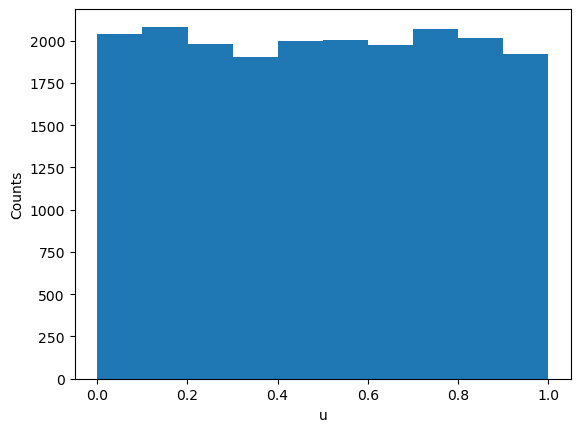

In [9]:
# Generate the u random variables and check the distribution
random_uniform = np.random.uniform(0, 1, 20000)

plt.hist(random_uniform)
plt.xlabel("u")
plt.ylabel("Counts")
plt.show()

In [10]:
# Generate Omega_m distribution by applying the inverse cumulative to u random numbers
omega_m_gen = interp_inverse_cumulative(random_uniform)

In [11]:
np.max(omega_m_gen)

np.float64(0.334254511423035)

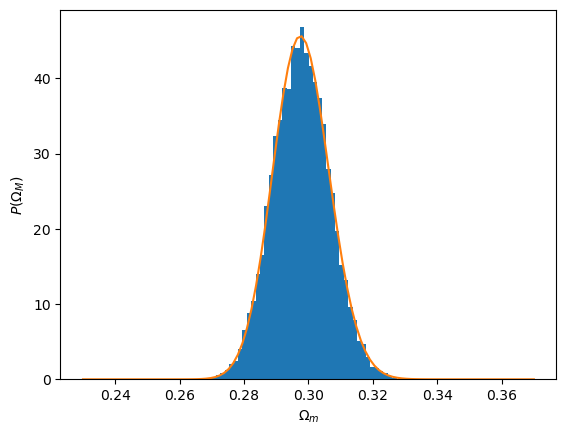

In [12]:
# Verify the distribution of the generated omega_m

_ = plt.hist(omega_m_gen, bins=50, density=True)
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$P(\Omega_M)$")
plt.plot(omega_m_values, posterior)
plt.plot()
plt.show()

In [13]:
print("Omega_m : {mean:2.4f}+-{std:2.4f}".format(mean=np.mean(omega_m_gen), std=np.std(omega_m_gen)))

Omega_m : 0.2978+-0.0088
